# Feature Extraction - Charité Dataset

**Objective:** Extract multi-domain features from windowed sensor data for FoG detection.

**Features extracted:**
- Time-domain: mean, std, skewness, kurtosis, RMS, median, IQR, cadence
- Frequency-domain: PSD peak, total energy, band powers, freezing index
- Wavelet: energy per level, entropy
- Nonlinear: sample entropy, fractal dimension (ENABLED)

**Pipeline:**
1. Load windowed LOSO splits
2. Initialize signal cleaner and feature extractor
3. Process all folds: clean signals → extract features → save CSVs
4. Analyze extracted features with visualizations

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm
from features import FeatureExtractor
from processing import SignalCleaner

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Windowed Data

In [6]:
# Load binary LOSO splits
data_path = Path('../../outputs/datasets_csv/charite_loso_windows_binary.pkl')

with open(data_path, 'rb') as f:
    loso_splits = pickle.load(f)

print(f"✅ Loaded {len(loso_splits)} LOSO folds")
print(f"   Total train windows: {sum([len(fold['y_train']) for fold in loso_splits]):,}")
print(f"   Total test windows: {sum([len(fold['y_test']) for fold in loso_splits]):,}")

✅ Loaded 16 LOSO folds
   Total train windows: 15,300
   Total test windows: 520


## 2. Initialize Cleaner and Extractor

In [7]:
# Signal cleaner (MAD-based outlier detection)
cleaner = SignalCleaner(
    outlier_thresh_mul=3.0,
    outlier_poly_order=3
)

print("✅ Signal cleaner initialized")
print(f"   MAD threshold: {cleaner.outlier_thresh_mul}")
print(f"   Polynomial order: {cleaner.outlier_poly_order}")

✅ Signal cleaner initialized
   MAD threshold: 3.0
   Polynomial order: 3


In [8]:
# Feature extractor
SAMPLING_RATE = 200  # Hz for Charité

extractor = FeatureExtractor(
    sampling_rate=SAMPLING_RATE,
    extract_time=True,
    extract_frequency=True,
    extract_wavelet=True,
    extract_nonlinear=True  # Enabled for robust cross-dataset pipeline
)

# Channel groups for per-sensor magnitude computation
# Charité: 12 channels — acc (0-2) + gyr (3-5) left foot, acc (6-8) + gyr (9-11) right foot
CHANNEL_GROUPS = {
    'acc_left_foot':  [0, 1, 2],
    'gyr_left_foot':  [3, 4, 5],
    'acc_right_foot': [6, 7, 8],
    'gyr_right_foot': [9, 10, 11],
}

print("✅ Feature extractor initialized")
print(f"   Sampling rate: {SAMPLING_RATE} Hz")
print(f"   Time-domain: ✅")
print(f"   Frequency-domain: ✅")
print(f"   Wavelet: ✅")
print(f"   Nonlinear: ✅")
print(f"   Channel groups: {list(CHANNEL_GROUPS.keys())}")

✅ Feature extractor initialized
   Sampling rate: 200 Hz
   Time-domain: ✅
   Frequency-domain: ✅
   Wavelet: ✅
   Nonlinear: ✅
   Channel groups: ['acc_left_foot', 'gyr_left_foot', 'acc_right_foot', 'gyr_right_foot']


## 3. Process All LOSO Folds

Extract features from all folds and save to CSV files.

In [9]:
# Output directory
feature_output_dir = Path('../../outputs/charite_features')
feature_output_dir.mkdir(parents=True, exist_ok=True)

print("🚀 Processing all LOSO folds...")
print("=" * 70)

for fold in tqdm(loso_splits, desc="Processing folds"):
    test_subject = fold['test_subject']

    # 1. Clean signals (remove outliers)
    X_train_clean = cleaner.clean_windows(fold['X_train'])
    X_test_clean  = cleaner.clean_windows(fold['X_test'])

    # 2. Extract features (parallel processing with all CPU cores)
    X_train_features = extractor.extract_from_windows(
        X_train_clean, n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)
    X_test_features = extractor.extract_from_windows(
        X_test_clean, n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)

    # 3. Save to CSV
    fold_dir = feature_output_dir / f'fold_subj_{test_subject}'
    fold_dir.mkdir(parents=True, exist_ok=True)

    X_train_features.to_csv(fold_dir / 'X_train_features.csv', index=False)
    pd.Series(fold['y_train'], name='label').to_csv(fold_dir / 'y_train.csv', index=False)
    pd.Series(fold['subjects_train'], name='subject').to_csv(fold_dir / 'subjects_train.csv', index=False)
    X_test_features.to_csv(fold_dir / 'X_test_features.csv', index=False)
    pd.Series(fold['y_test'], name='label').to_csv(fold_dir / 'y_test.csv', index=False)

print("\n" + "=" * 70)
print(f"✅ Feature extraction complete for {len(loso_splits)} folds")
print(f"📁 Output directory: {feature_output_dir}")
print("=" * 70)

🚀 Processing all LOSO folds...


Processing folds:   0%|          | 0/16 [00:00<?, ?it/s]

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   14.7s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   23.9s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   28.6s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   33.4s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   37.0s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   43.5s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   48.6s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   54.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   59.8s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

🚀 Extracting features in parallel (-1 jobs)...


...

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   22.1s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   31.3s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   36.4s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   42.6s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   48.3s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   55.8s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    4.9s remaining:   14.8s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    4.9s remaining:    6.9s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    4.9s remaining:    3.5s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    4.9s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    5.0s finished
Processing folds: 100%|██████████| 16/16 [1:31:33<00:00, 343.36s/it]


✅ Feature extraction complete for 16 folds
📁 Output directory: ..\..\outputs\charite_features


## 4. Load Sample Features for Analysis

Load features from the first fold for visualization and analysis.

In [10]:
# Load first fold for analysis
sample_fold_dir = feature_output_dir / 'fold_subj_S01'

X_train_features = pd.read_csv(sample_fold_dir / 'X_train_features.csv')
y_train = pd.read_csv(sample_fold_dir / 'y_train.csv').squeeze()
X_test_features = pd.read_csv(sample_fold_dir / 'X_test_features.csv')
y_test = pd.read_csv(sample_fold_dir / 'y_test.csv').squeeze()

print(f"📊 Loaded features from: {sample_fold_dir.name}")
print(f"   Train: {X_train_features.shape}")
print(f"   Test: {X_test_features.shape}")
print(f"   Features: {X_train_features.shape[1]}")
print(f"\n📋 First 10 features:")
for i, col in enumerate(X_train_features.columns[:10], 1):
    print(f"   {i}. {col}")

📊 Loaded features from: fold_subj_S01
   Train: (990, 449)
   Test: (15, 449)
   Features: 449

📋 First 10 features:
   1. ch0_mean
   2. ch0_std
   3. ch0_skew
   4. ch0_kurt
   5. ch0_median
   6. ch0_iqr
   7. ch0_rms
   8. ch0_peak_to_peak
   9. ch0_zero_crossing_rate
   10. ch0_psd_peak_freq


## 5. Feature Statistics

In [11]:
# Statistical summary
print("📈 Feature Statistics (Train Set):")
print(X_train_features.describe())

📈 Feature Statistics (Train Set):
         ch0_mean     ch0_std    ch0_skew    ch0_kurt  ch0_median     ch0_iqr  \
count  990.000000  990.000000  990.000000  990.000000  990.000000  990.000000   
mean    -1.802489    0.423878   -0.066206    1.478307   -1.790470    0.358234   
std      0.756918    0.525199    0.273088    1.173150    0.743833    0.436711   
min     -4.291216    0.027968   -1.118934   -1.241365   -4.538760    0.008427   
25%     -2.184605    0.098894   -0.236672    0.568453   -2.176397    0.111180   
50%     -1.774709    0.215640   -0.047373    1.398334   -1.760298    0.198002   
75%     -1.427571    0.582997    0.100618    2.232633   -1.420028    0.441147   
max      0.492030    4.725631    1.150439    6.590029    0.489765    3.373150   

          ch0_rms  ch0_peak_to_peak  ch0_zero_crossing_rate  \
count  990.000000        990.000000              990.000000   
mean     1.929348          2.733040                0.017495   
std      0.744793          3.282227            

## 6. Feature Distributions: FoG vs No FoG

Compare key features between FoG and No FoG windows.

📊 Class Distribution:
   No FoG: 276 windows (27.9%)
   FoG: 714 windows (72.1%)


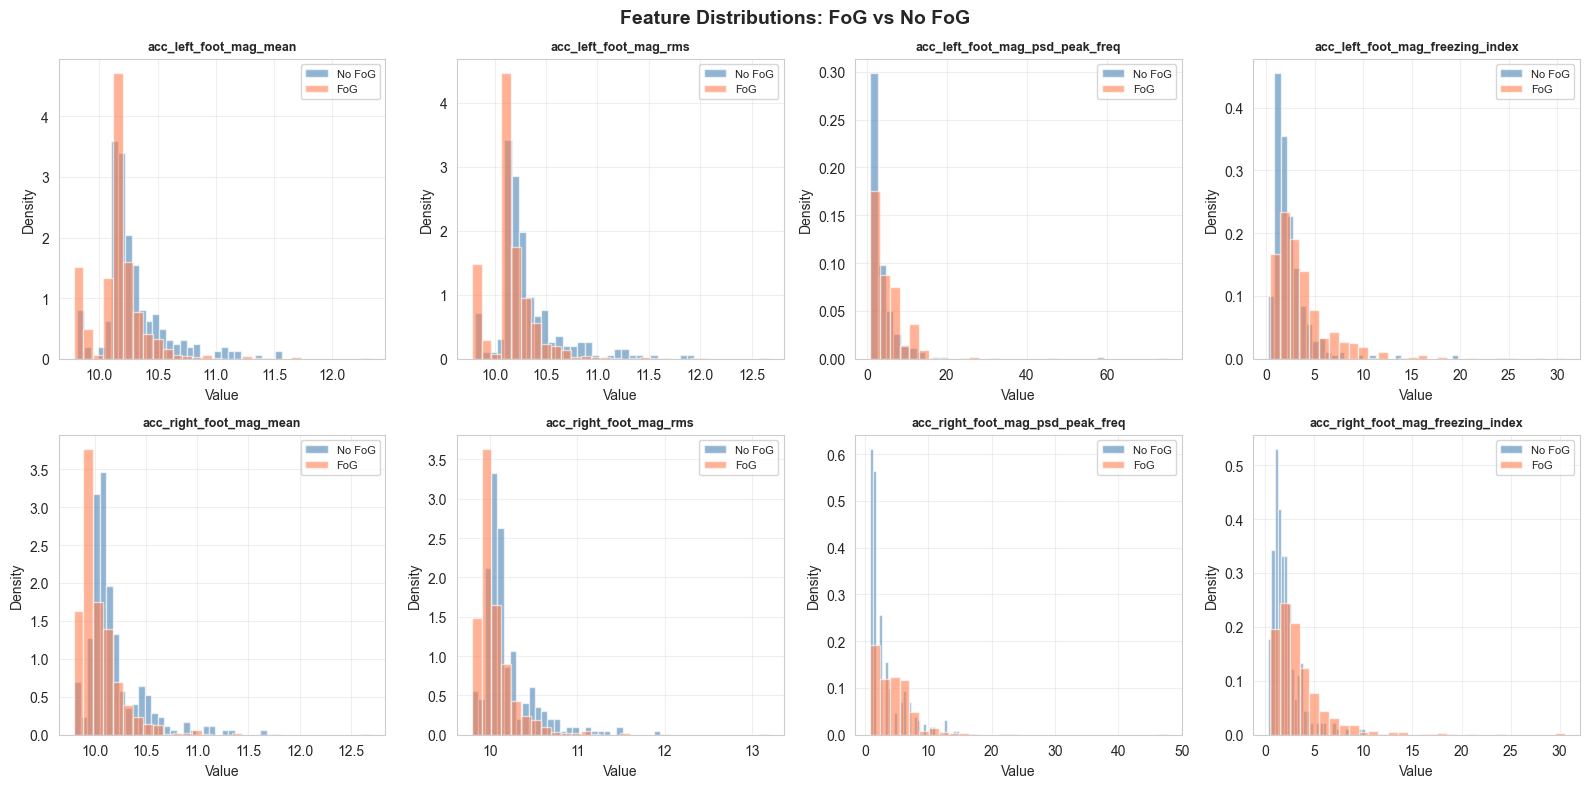

In [12]:
# Separate by class (replace inf so histograms and Cohen's d are not distorted)
features_no_fog = X_train_features[y_train == 0].replace([np.inf, -np.inf], np.nan)
features_fog    = X_train_features[y_train == 1].replace([np.inf, -np.inf], np.nan)

print(f"📊 Class Distribution:")
print(f"   No FoG: {len(features_no_fog):,} windows ({len(features_no_fog)/len(X_train_features)*100:.1f}%)")
print(f"   FoG: {len(features_fog):,} windows ({len(features_fog)/len(X_train_features)*100:.1f}%)")

# Select representative features (per-group magnitudes)
feature_subset = [
    'acc_left_foot_mag_mean', 'acc_left_foot_mag_rms',
    'acc_left_foot_mag_psd_peak_freq', 'acc_left_foot_mag_freezing_index',
    'acc_right_foot_mag_mean', 'acc_right_foot_mag_rms',
    'acc_right_foot_mag_psd_peak_freq', 'acc_right_foot_mag_freezing_index',
]

# Filter to existing features
feature_subset = [f for f in feature_subset if f in X_train_features.columns]

# Visualize distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feat in enumerate(feature_subset[:8]):
    axes[i].hist(features_no_fog[feat].dropna(), bins=30, alpha=0.6, 
                label='No FoG', color='steelblue', density=True)
    axes[i].hist(features_fog[feat].dropna(), bins=30, alpha=0.6, 
                label='FoG', color='coral', density=True)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Hide unused subplots
for i in range(len(feature_subset), 8):
    axes[i].axis('off')

plt.suptitle('Feature Distributions: FoG vs No FoG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance by Variance

Identify features with highest variance (potentially most discriminative).

📊 Top 15 Features by Variance:
 1. gyr_right_foot_mag_wavelet_energy_0 17292128276349.71
 2. gyr_left_foot_mag_wavelet_energy_0  13967794116278.93
 3. ch9_wavelet_energy_0                12584199418925.68
 4. ch3_wavelet_energy_0                9116353685782.92
 5. ch5_wavelet_energy_0                302368649256.88
 6. ch11_wavelet_energy_0               246470717244.56
 7. ch10_wavelet_energy_0               120645262056.30
 8. ch4_wavelet_energy_0                84288334421.80
 9. ch9_wavelet_energy_1                18081457619.19
10. ch3_wavelet_energy_1                16786177453.11
11. gyr_right_foot_mag_wavelet_energy_1 11286950756.85
12. gyr_left_foot_mag_wavelet_energy_1  9202540495.54
13. ch9_wavelet_energy_2                7316715495.26
14. ch3_wavelet_energy_2                4978837927.95
15. gyr_right_foot_mag_wavelet_energy_2 3448091611.64


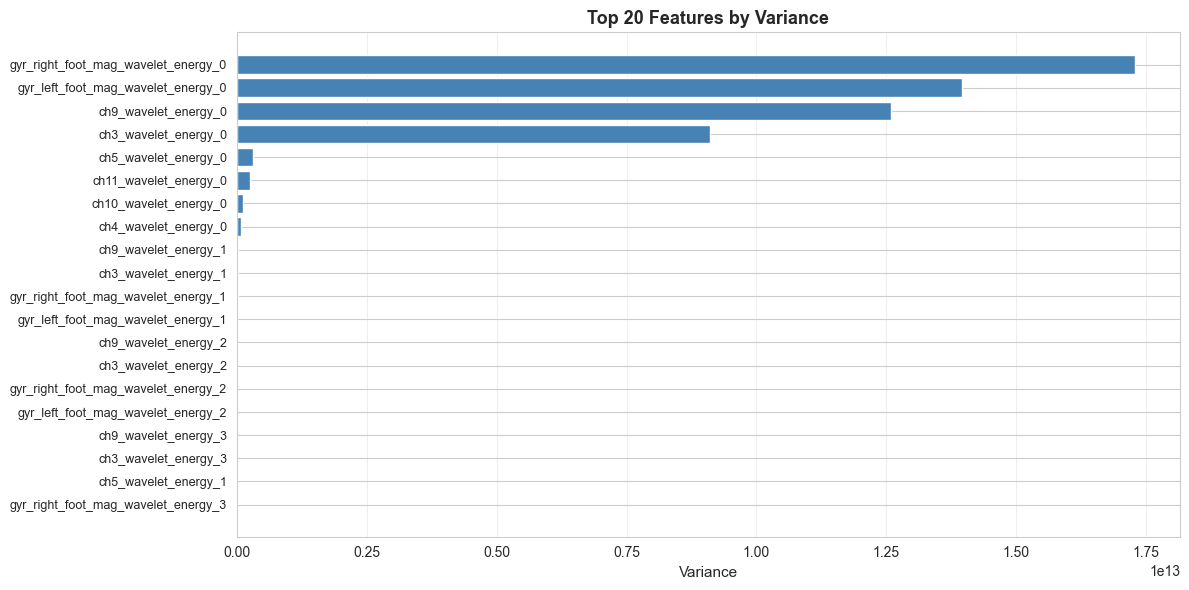

In [13]:
# Calculate variance for each feature (replace inf with NaN before var to avoid inf results)
feature_variance = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .var()
    .sort_values(ascending=False)
)

print("📊 Top 15 Features by Variance:")
print("=" * 60)
for i, (feat, var) in enumerate(feature_variance.head(15).items(), 1):
    print(f"{i:2d}. {feat:35s} {var:12.2f}")

# Visualize top features by variance
fig, ax = plt.subplots(figsize=(12, 6))
top_features = feature_variance.dropna().head(20)
ax.barh(range(len(top_features)), top_features.values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.set_xlabel('Variance', fontsize=11)
ax.set_title('Top 20 Features by Variance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Feature Correlation Analysis

Identify highly correlated features (potential redundancy).

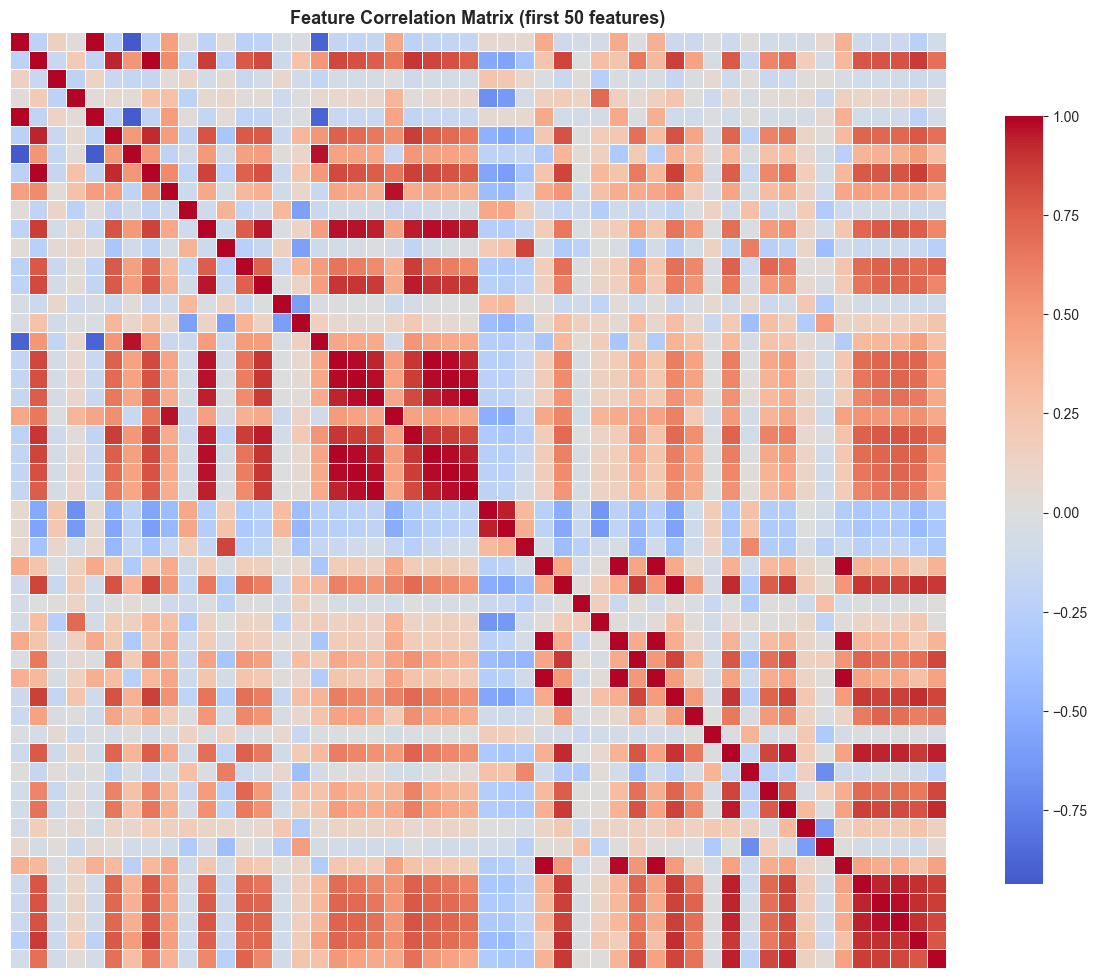


⚠️  Highly correlated pairs (|r| > 0.9): 56

Top 10 correlations:
  ch0_wavelet_energy_3           <-> ch0_wavelet_var_3             :  1.000
  ch0_wavelet_energy_2           <-> ch0_wavelet_var_2             :  1.000
  ch0_wavelet_energy_1           <-> ch0_wavelet_var_1             :  1.000
  ch0_mean                       <-> ch0_median                    :  0.997
  ch1_mean                       <-> ch1_rms                       :  0.995
  ch0_std                        <-> ch0_peak_to_peak              :  0.995
  ch1_mean                       <-> ch1_median                    :  0.994
  ch1_rms                        <-> ch1_wavelet_energy_0          :  0.993
  ch1_std                        <-> ch1_peak_to_peak              :  0.990
  ch1_median                     <-> ch1_rms                       :  0.988


In [14]:
# Compute correlation matrix (replace inf with NaN before corr to avoid propagation)
n_features_viz = min(50, X_train_features.shape[1])
features_sample = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .iloc[:, :n_features_viz]
)
corr_matrix = features_sample.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
           xticklabels=False, yticklabels=False)
ax.set_title(f'Feature Correlation Matrix (first {n_features_viz} features)', 
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if np.isfinite(val) and abs(val) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                val
            ))

print(f"\n⚠️  Highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 correlations:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1:30s} <-> {feat2:30s}: {corr:6.3f}")

## 9. Class Separability Analysis

Measure how well features separate FoG from No FoG using effect size (Cohen's d).

📊 Top 15 Features by Effect Size (Cohen's d):
   Higher effect size = better class separability
   d > 0.8: Large effect
   d > 0.5: Medium effect
   d > 0.2: Small effect
 1. ch7_approx_entropy                  d=1.277  (Large)
 2. ch1_approx_entropy                  d=1.256  (Large)
 3. ch0_approx_entropy                  d=1.228  (Large)
 4. ch8_approx_entropy                  d=1.216  (Large)
 5. ch6_approx_entropy                  d=1.189  (Large)
 6. ch1_sample_entropy                  d=1.180  (Large)
 7. ch7_sample_entropy                  d=1.171  (Large)
 8. ch11_approx_entropy                 d=1.167  (Large)
 9. ch2_approx_entropy                  d=1.162  (Large)
10. ch0_sample_entropy                  d=1.118  (Large)
11. ch8_sample_entropy                  d=1.110  (Large)
12. ch2_sample_entropy                  d=1.107  (Large)
13. ch5_approx_entropy                  d=1.092  (Large)
14. acc_right_foot_mag_approx_entropy   d=1.081  (Large)
15. ch0_locomotion_band_index 

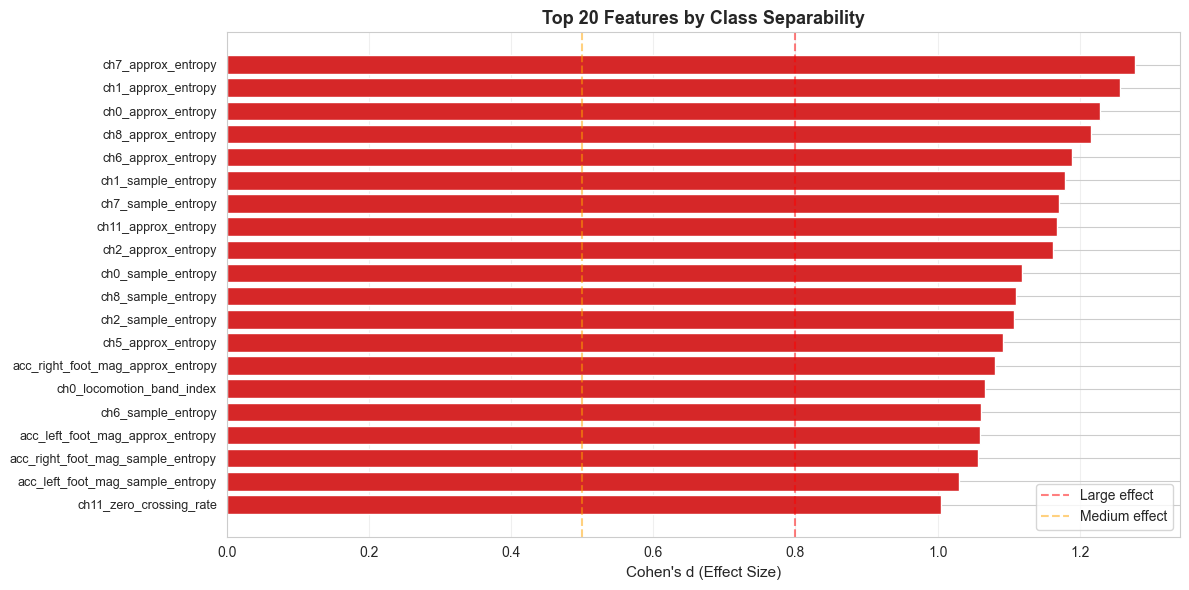

In [15]:
# Calculate Cohen's d for each feature
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
    return abs((mean1 - mean2) / pooled_std) if pooled_std > 0 else 0

effect_sizes = {}
for col in X_train_features.columns:
    d = cohens_d(features_no_fog[col].dropna(), features_fog[col].dropna())
    effect_sizes[col] = d

effect_sizes = pd.Series(effect_sizes).sort_values(ascending=False)

print("📊 Top 15 Features by Effect Size (Cohen's d):")
print("=" * 70)
print("   Higher effect size = better class separability")
print("   d > 0.8: Large effect")
print("   d > 0.5: Medium effect")
print("   d > 0.2: Small effect")
print("=" * 70)
for i, (feat, d) in enumerate(effect_sizes.head(15).items(), 1):
    magnitude = "Large" if d > 0.8 else "Medium" if d > 0.5 else "Small" if d > 0.2 else "Negligible"
    print(f"{i:2d}. {feat:35s} d={d:5.3f}  ({magnitude})")

# Visualize top features by effect size
fig, ax = plt.subplots(figsize=(12, 6))
top_effects = effect_sizes.head(20)
colors = ['#d62728' if d > 0.8 else '#ff7f0e' if d > 0.5 else '#2ca02c' for d in top_effects.values]
ax.barh(range(len(top_effects)), top_effects.values, color=colors)
ax.set_yticks(range(len(top_effects)))
ax.set_yticklabels(top_effects.index, fontsize=9)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=11)
ax.set_title('Top 20 Features by Class Separability', fontsize=13, fontweight='bold')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large effect')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium effect')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Summary

In [16]:
# Summary statistics
total_train = sum([len(fold['y_train']) for fold in loso_splits])
total_test = sum([len(fold['y_test']) for fold in loso_splits])

print("=" * 70)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print(f"\n📊 Feature Configuration:")
print(f"   Time-domain: ✅ Enabled")
print(f"   Frequency-domain: ✅ Enabled")
print(f"   Wavelet: ✅ Enabled")
print(f"   Nonlinear: ✅ Enabled")

print(f"\n📈 Processing Statistics:")
print(f"   LOSO folds: {len(loso_splits)}")
print(f"   Total train windows: {total_train:,}")
print(f"   Total test windows: {total_test:,}")
print(f"   Features per window: {X_train_features.shape[1]}")

print(f"\n🧹 Signal Cleaning:")
print(f"   Method: MAD-based outlier detection")
print(f"   Interpolation: Polynomial (order 3)")
print(f"   Threshold: 3.0 × MAD")

print(f"\n💾 Output:")
print(f"   Directory: {feature_output_dir}")
print(f"   Files per fold: X_train_features.csv, y_train.csv, X_test_features.csv, y_test.csv")

print(f"\n🎯 Key Insights:")
print(f"   Top feature (variance): {feature_variance.index[0]}")
print(f"   Top feature (effect size): {effect_sizes.index[0]} (d={effect_sizes.iloc[0]:.3f})")
print(f"   Highly correlated pairs: {len(high_corr_pairs)}")

print("\n" + "=" * 70)
print("✅ Dataset ready for training!")
print("📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb")
print("=" * 70)

FEATURE EXTRACTION SUMMARY

📊 Feature Configuration:
   Time-domain: ✅ Enabled
   Frequency-domain: ✅ Enabled
   Wavelet: ✅ Enabled
   Nonlinear: ✅ Enabled

📈 Processing Statistics:
   LOSO folds: 16
   Total train windows: 15,300
   Total test windows: 520
   Features per window: 449

🧹 Signal Cleaning:
   Method: MAD-based outlier detection
   Interpolation: Polynomial (order 3)
   Threshold: 3.0 × MAD

💾 Output:
   Directory: ..\..\outputs\charite_features
   Files per fold: X_train_features.csv, y_train.csv, X_test_features.csv, y_test.csv

🎯 Key Insights:
   Top feature (variance): gyr_right_foot_mag_wavelet_energy_0
   Top feature (effect size): ch7_approx_entropy (d=1.277)
   Highly correlated pairs: 56

✅ Dataset ready for training!
📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb
